### Data Wrangling: Ecommerce

In [19]:
# Import libraries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns


In [20]:
# Load customers_enriched, products_enriched, and orders_enriched
from pathlib import Path

data_dir = Path("../data/processed")
if not data_dir.exists():
    data_dir = Path("data/processed")

customers_enriched = pd.read_csv(data_dir / "customers_enriched.csv")
products_enriched = pd.read_csv(data_dir / "products_enriched.csv")
orders_enriched = pd.read_csv(data_dir / "orders_enriched.csv")

print("Loaded:")
print("customers_enriched:", customers_enriched.shape)
print("products_enriched:", products_enriched.shape)
print("orders_enriched:", orders_enriched.shape)

Loaded:
customers_enriched: (200, 12)
products_enriched: (40, 16)
orders_enriched: (5000, 10)


In [21]:
print(customers_enriched['customer_id'].is_unique)
print(products_enriched['product_id'].is_unique)

True
True


In [22]:
# Merge customers_enriched , products_enriched and order_enriched into a single dataset
orders_master = orders_enriched.merge(customers_enriched, on="customer_id", how="left")
orders_master = orders_master.merge(products_enriched, on="product_id", how="left")

In [30]:
df = orders_master

In [31]:
# Shape
df.shape

(5000, 36)

In [32]:
# Null and duplicates check
print("Null values :",orders_master.isnull().sum())
print("Duplicate values:",orders_master.duplicated().sum())

Null values : order_id                0
customer_id             0
product_id              0
order_date              0
quantity                0
unit_price              0
discount                0
region_x                0
status                  0
revenue                 0
name                    0
age                     0
gender                  0
city                    0
region_y                0
signup_date             0
membership_tier         0
signup_year             0
tenure_days             0
age_group               0
tenure_months           0
product_name            0
category                0
cost_price              0
selling_price           0
stock_available         0
profit                  0
margin                  0
inventory_cost          0
inventory_revenue       0
risk_score              0
high_stock_flag         0
low_margin_flag         0
inventory_risk          0
inventory_risk_label    0
price_bucket            0
dtype: int64
Duplicate values: 0


In [33]:
# Columns 
df.columns

Index(['order_id', 'customer_id', 'product_id', 'order_date', 'quantity',
       'unit_price', 'discount', 'region_x', 'status', 'revenue', 'name',
       'age', 'gender', 'city', 'region_y', 'signup_date', 'membership_tier',
       'signup_year', 'tenure_days', 'age_group', 'tenure_months',
       'product_name', 'category', 'cost_price', 'selling_price',
       'stock_available', 'profit', 'margin', 'inventory_cost',
       'inventory_revenue', 'risk_score', 'high_stock_flag', 'low_margin_flag',
       'inventory_risk', 'inventory_risk_label', 'price_bucket'],
      dtype='str')

In [35]:
# Save dataset
output_path = Path("data/processed/orders_master.csv")
if not output_path.parent.exists():
    output_path = Path("../data/processed/orders_master.csv")

output_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(output_path, index=False)

#### Insights

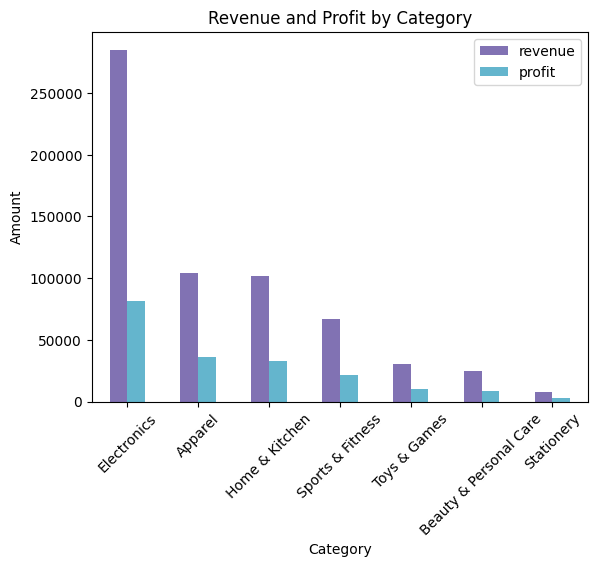

In [67]:
# Revenue and Profit by category
cat_perf = df.groupby('category')[['revenue','profit']].sum().sort_values(by='revenue', ascending=False)

cat_perf.plot(kind='bar',color=['#8172B3','#64B5CD'])
plt.title('Revenue and Profit by Category')
plt.xlabel('Category')
plt.ylabel('Amount')
plt.xticks(rotation=45)
plt.show()

Electronics leads revenue ($285,356.54), while Electronics leads profit ($81,636.43).

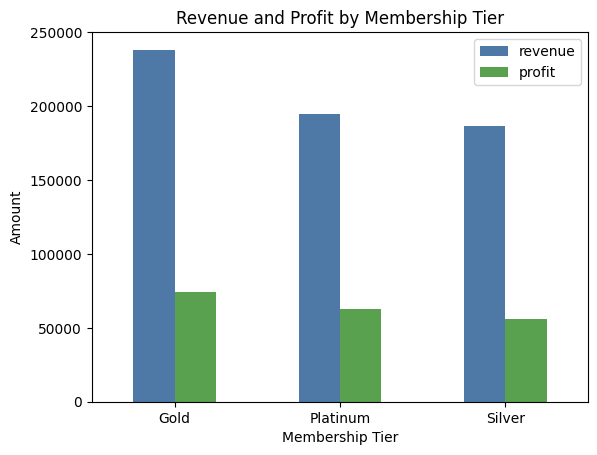

In [64]:
# Customer segment value
tier_perf = df.groupby('membership_tier')[['revenue','profit']].sum()

tier_perf.plot(kind='bar',color=['#4E79A7','#59A14F'])
plt.title('Revenue and Profit by Membership Tier')
plt.xlabel('Membership Tier')
plt.ylabel('Amount')
plt.xticks(rotation=0)
plt.show()

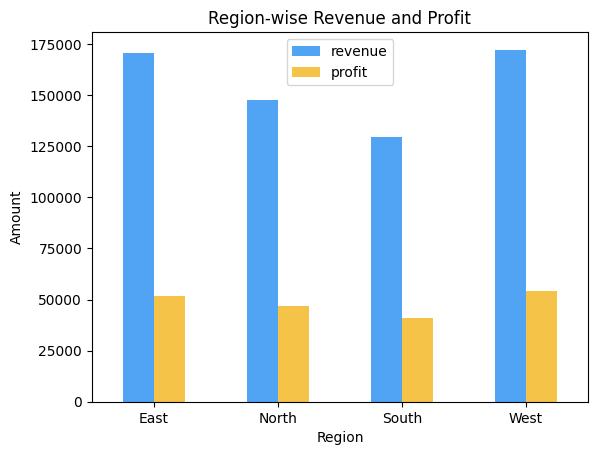

In [66]:
# Region wise performance
region_perf = df.groupby('region_x')[['revenue','profit']].sum()

region_perf.plot(kind='bar',color=["#50A4F3", "#F4C347"])
plt.title('Region-wise Revenue and Profit')
plt.xlabel('Region')
plt.ylabel('Amount')
plt.xticks(rotation=0)
plt.show()

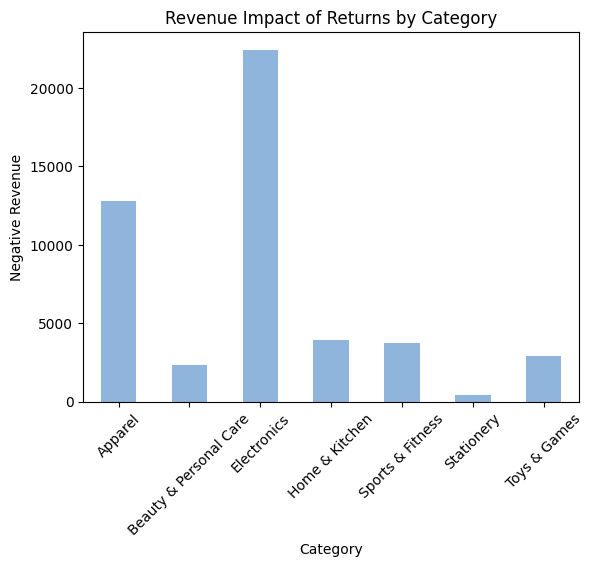

In [61]:
# Return impact by category
returns = df[df['status']=='Returned'].groupby('category')['revenue'].sum()

returns.plot(kind='bar',color="#8FB5DD")
plt.title('Revenue Impact of Returns by Category')
plt.xlabel('Category')
plt.ylabel('Negative Revenue')
plt.xticks(rotation=45)
plt.show()

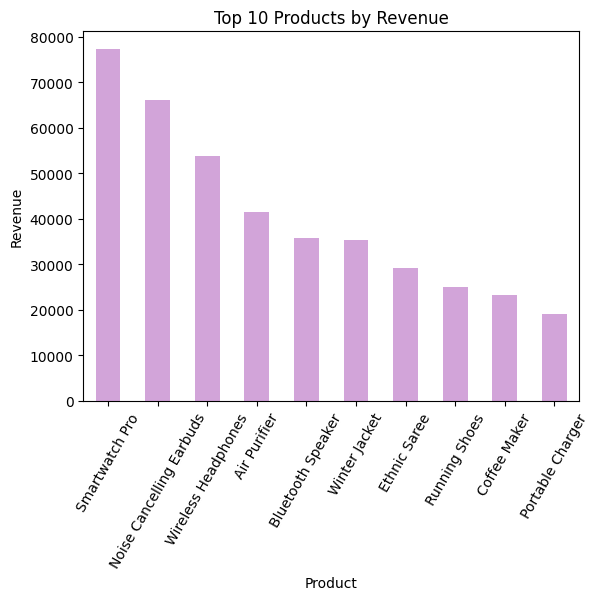

In [59]:
# Top products (Top 10)
top_products = df.groupby('product_name')['revenue'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar',color="#D2A4D9")
plt.title('Top 10 Products by Revenue')
plt.xlabel('Product')
plt.ylabel('Revenue')
plt.xticks(rotation=60)
plt.show()

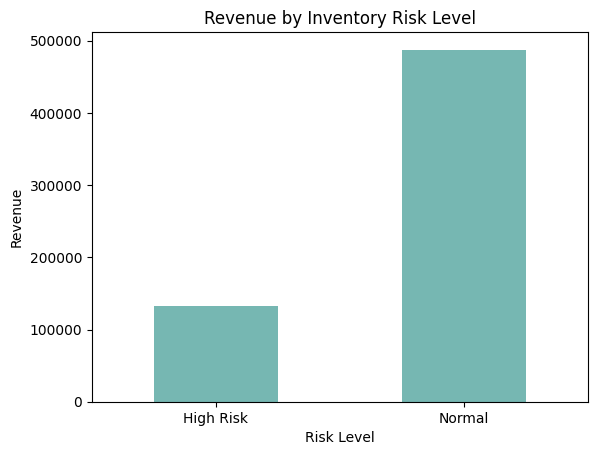

In [55]:
# Iventory Risk vs Revenue
risk_perf = df.groupby('inventory_risk_label')['revenue'].sum()

risk_perf.plot(kind='bar',color='#76B7B2')
plt.title('Revenue by Inventory Risk Level')
plt.xlabel('Risk Level')
plt.ylabel('Revenue')
plt.xticks(rotation=0)
plt.show()

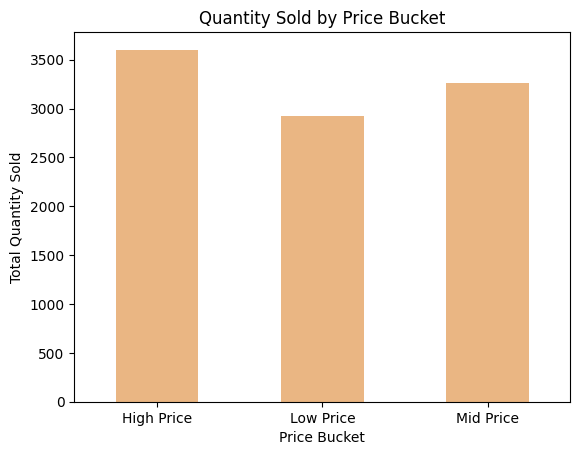

In [60]:
# Price sensitivity
price_perf = df.groupby('price_bucket')['quantity'].sum()

price_perf.plot(kind='bar', color="#EAB683")
plt.title('Quantity Sold by Price Bucket')
plt.xlabel('Price Bucket')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=0)
plt.show()

In [47]:
# Customer lifetime value (table form)
cltv_table = (
    df.groupby('customer_id', as_index=False)['revenue']
      .sum()
      .rename(columns={'revenue': 'customer_lifetime_value'})
      .sort_values('customer_lifetime_value', ascending=False)
      .reset_index(drop=True)
)

cltv_table.head(10)

,customer_id,customer_lifetime_value
0,C1154,8715.0185
1,C1102,7814.3715
2,C1180,7347.5990
3,C1071,7312.9610
4,C1114,7072.1620
5,C1144,6272.4720
6,C1148,6154.6885
7,C1002,6131.9960
8,C1107,6023.2550
9,C1153,5990.0670
